In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split 

In [2]:
df= pd.read_csv("dataset/09-iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

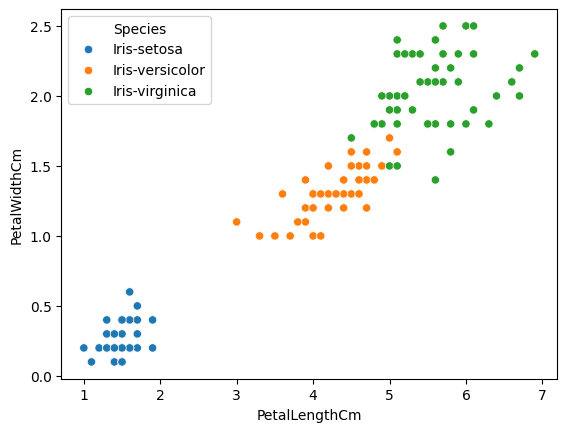

In [6]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue= df["Species"])
plt.show()

In [7]:
df= df.drop("Id", axis=1)

In [8]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
X= df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm","PetalWidthCm"]].values
y= df["Species"].values


In [10]:
# label encoding yapmalıyız çünkü eğitimdeki fonksiyonlar matematiksel işlemler yapabiliyor. Species değerlerini encode etmemiz lazım.
# Örneğin Iris-setosa= 0 gibisine bunu yapan bir scikit-learn fonksiyonu var

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le= LabelEncoder() 
y= le.fit_transform(y)

In [13]:
y # görüldüğü üzere 3 farklı sınıfa 3 farklı değer verilmesi için encoding işlemi yapıldı.

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [14]:
# stratify= hedef stratify her sınıftan oransal ayrım yapmayı sağlar yani gözardı etmez
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
X_train= torch.tensor(X_train, dtype= torch.float32)
X_test= torch.tensor(X_test, dtype= torch.float32)

y_train= torch.tensor(y_train, dtype= torch.long)
y_test= torch.tensor(y_test, dtype= torch.long)

In [16]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

torch.Size([120, 4]) torch.Size([30, 4]) torch.Size([120]) torch.Size([30])


In [23]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features = 4, out_features = 16)
        self.layer_2 = nn.Linear(in_features = 16, out_features = 16)
        self.layer_3 = nn.Linear(in_features = 16, out_features = 3)
        self.relu = nn.ReLU()

    def forward(self,x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [24]:
model = IrisClassifier()

In [25]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.001)

In [26]:
def calculate_accuracy(y_true : torch.tensor, y_pred : torch.tensor) -> float:
    correct = torch.eq(y_true, y_pred).sum().item()
    accuracy = correct / len(y_pred) * 100
    return accuracy

In [27]:
y_logits = model(X_test)

In [28]:
y_pred_probs = torch.softmax(y_logits, dim = 1)

In [29]:
epochs = 200

# let's also try to plot loss - accuracy later on (totally optional)
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    ### TRAIN ###
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    #pred = torch.argmax(logits, dim=1) (we can get preds like this or the line below. cross entropy loss already containts softmax calculation so it won't change the outcome)
    pred = torch.softmax(logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    acc = calculate_accuracy(y_train, pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)


    ### TEST ###
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = calculate_accuracy(y_test, test_pred)

    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.1267 | Acc: 33.33% | Test Loss: 1.1227 | Test Acc: 33.33%
Epoch 20 | Loss: 1.0485 | Acc: 45.83% | Test Loss: 1.0460 | Test Acc: 50.00%
Epoch 40 | Loss: 0.9888 | Acc: 74.17% | Test Loss: 0.9853 | Test Acc: 76.67%
Epoch 60 | Loss: 0.9140 | Acc: 66.67% | Test Loss: 0.9085 | Test Acc: 66.67%
Epoch 80 | Loss: 0.8076 | Acc: 70.00% | Test Loss: 0.8000 | Test Acc: 76.67%
Epoch 100 | Loss: 0.6852 | Acc: 93.33% | Test Loss: 0.6769 | Test Acc: 90.00%
Epoch 120 | Loss: 0.5625 | Acc: 94.17% | Test Loss: 0.5564 | Test Acc: 90.00%
Epoch 140 | Loss: 0.4667 | Acc: 95.00% | Test Loss: 0.4652 | Test Acc: 93.33%
Epoch 160 | Loss: 0.3916 | Acc: 95.83% | Test Loss: 0.3941 | Test Acc: 93.33%
Epoch 180 | Loss: 0.3309 | Acc: 97.50% | Test Loss: 0.3371 | Test Acc: 96.67%


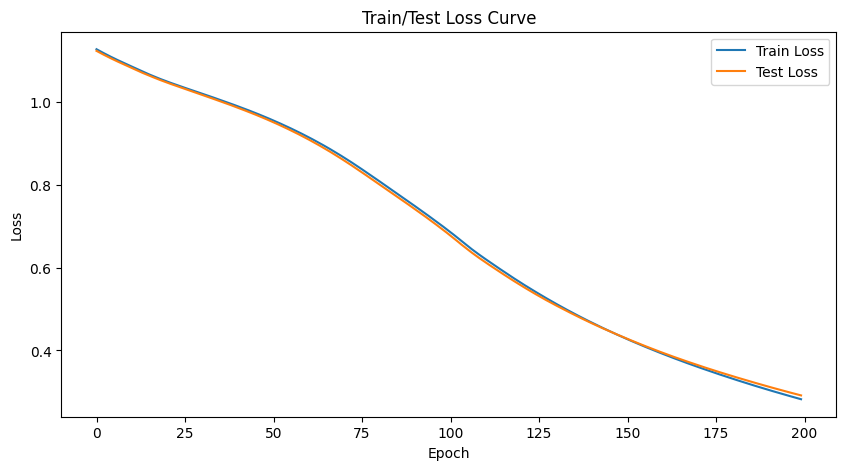

In [30]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")
plt.legend()
plt.show()

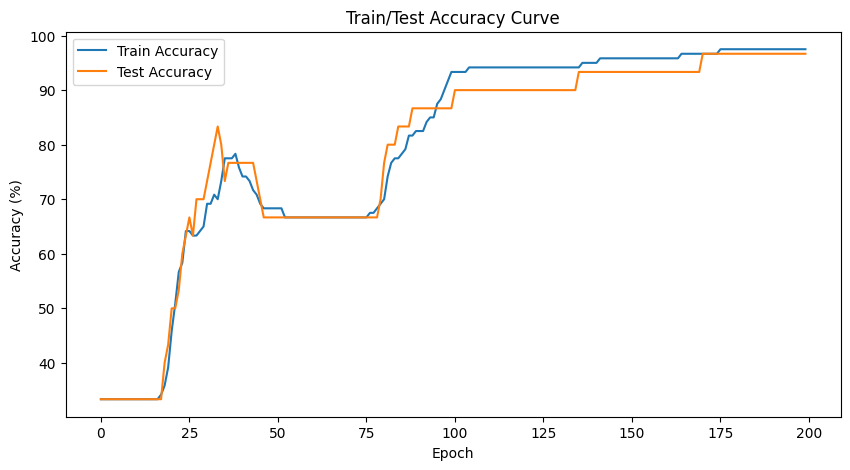

In [31]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")
plt.legend()
plt.show()